# Multi-Asset Strategy Comparison: Standard vs Enhanced PPO
**Objective:** Compare Standard Deep RL PPO against an 'Enhanced' PPO (High Entropy + Linear LR) and Traditional Baselines.
- **Strategies:**
  1. **DeepRL PPO (Baseline)**: Pre-trained Standard Model.
  2. **DeepRL PPO (Enhanced)**: Trained with `ent_coef=0.05` and Linear Learning Rate Schedule.
  3. **Markowitz**: Mean-Variance Optimization.
  4. **Equal Weight**: 1/N allocation.
  5. **Buy & Hold**: Initial allocation held.

In [13]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import os
from scipy.optimize import minimize

# Ensure plots look nice
plt.style.use('ggplot')

## 1. Load Data & Feature Engineering

In [14]:
# Load Multi-Asset Data
file_path = 'real_crypto_data.csv'
try:
    df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')
    print("Loaded Assets:", df.columns.tolist())
except FileNotFoundError:
    print("File not found. Generating dummy.")
    dates = pd.date_range(start='2023-01-01', periods=1000)
    df = pd.DataFrame(np.random.randn(1000, 5), index=dates, columns=['BTC','ETH','XRP','LTC','BCH'])
    df = (1 + df.pct_change().fillna(0)).cumprod() * 100

def get_market_features(df):
    returns = df.pct_change().fillna(0)
    volatility = returns.rolling(window=20).std().fillna(0)
    sma50 = df.rolling(window=50).mean()
    momentum = (df / sma50 - 1).fillna(0)
    return returns, volatility, momentum

returns_df, vol_df, mom_df = get_market_features(df)
assets = df.columns.tolist()
n_assets = len(assets)

# Split Data
train_split_idx = int(len(df) * 0.7)
test_df = df.iloc[train_split_idx:]
test_returns = returns_df.iloc[train_split_idx:]
test_vol = vol_df.iloc[train_split_idx:]
test_mom = mom_df.iloc[train_split_idx:]

print("Test Data Shape:", test_df.shape)

Loaded Assets: ['BCH', 'BTC', 'ETH', 'LTC', 'XRP']
Test Data Shape: (329, 5)


## 2. Environment Definitions

In [15]:
class MultiAssetCryptoEnv(gym.Env):
    def __init__(self, price_df, returns_df, vol_df, mom_df):
        super(MultiAssetCryptoEnv, self).__init__()
        self.price_df = price_df
        self.returns_df = returns_df
        self.vol_df = vol_df
        self.mom_df = mom_df
        self.assets = price_df.columns
        self.n_assets = len(self.assets)
        self.action_space = spaces.Box(low=0, high=1, shape=(self.n_assets + 1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.n_assets * 3,), dtype=np.float32)
        self.current_step = 0
        self.max_steps = len(price_df) - 1

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        return self._get_obs(), {}

    def _get_obs(self):
        r = self.returns_df.iloc[self.current_step].values
        v = self.vol_df.iloc[self.current_step].values
        m = self.mom_df.iloc[self.current_step].values
        return np.concatenate([r, v, m]).astype(np.float32)

    def step(self, action):
        weights = np.exp(action) / np.sum(np.exp(action))
        asset_weights = weights[:-1]
        cash_weight = weights[-1]
        
        if self.current_step >= self.max_steps:
            return self._get_obs(), 0, True, False, {}
            
        next_day_returns = self.returns_df.iloc[self.current_step + 1].values
        portfolio_return = np.sum(asset_weights * next_day_returns)
        reward = np.log(1 + portfolio_return)
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        info = {'return': portfolio_return, 'weights': asset_weights, 'cash': cash_weight}
        return self._get_obs(), reward, terminated, False, info

# LSTM Predictor Model (PyTorch)
class LSTMPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(LSTMPredictor, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        out = self.dropout(hn[-1])
        out = self.fc(out)
        return out


## 3. Training & Model Loading

In [16]:
# 1. Load Standard PPO (Baseline)
model_path = "./best_model_ppo/best_model"
if os.path.exists(model_path + ".zip"):
    model_baseline = PPO.load(model_path)
    print("Loaded DeepRL PPO (Baseline).")
else:
    print("Baseline model not found! Using dummy baseline.")
    dummy_env = MultiAssetCryptoEnv(test_df, test_returns, test_vol, test_mom)
    model_baseline = PPO("MlpPolicy", dummy_env)

# 2. Train Enhanced PPO (Linear LR + High Entropy)
def linear_schedule(initial_value):
    """
    Linear learning rate schedule.
    :param initial_value: (float or str)
    :return: (function)
    """
    if isinstance(initial_value, str):
        initial_value = float(initial_value)

    def func(progress_remaining: float) -> float:
        """
        Progress will decrease from 1 (beginning) to 0
        :param progress_remaining: (float)
        :return: (float)
        """
        return progress_remaining * initial_value

    return func

print("Training DeepRL PPO (Enhanced)...\nParams: ent_coef=0.05, lr=Linear Schedule")

# Prepare Train Env
train_df_slice = df.iloc[:train_split_idx]
train_returns_slice = returns_df.iloc[:train_split_idx]
train_vol_slice = vol_df.iloc[:train_split_idx]
train_mom_slice = mom_df.iloc[:train_split_idx]

train_env = MultiAssetCryptoEnv(train_df_slice, train_returns_slice, train_vol_slice, train_mom_slice)
train_env = DummyVecEnv([lambda: train_env])

# Initialize Model with requested params
model_enhanced = PPO(
    "MlpPolicy", 
    train_env, 
    verbose=0, 
    ent_coef=0.05,  # Increased entropy coefficient
    learning_rate=linear_schedule(3e-4) # Linear decay
)
model_enhanced.learn(total_timesteps=10000)
print("DeepRL PPO (Enhanced) Training Complete.")

Baseline model not found! Using dummy baseline.
Training DeepRL PPO (Enhanced)...
Params: ent_coef=0.05, lr=Linear Schedule
DeepRL PPO (Enhanced) Training Complete.


## 4. Evaluation Loop

In [17]:
# --- AI-Gated Classifier Training (Random Forest) ---
print('Training AI Gatekeeper (Bul/Bear Classifier)...')
# Target: Market Bull (1) if Average Return > 0 next day
market_ret = returns_df.mean(axis=1)
feat = pd.DataFrame(index=returns_df.index)
feat['Vol_20'] = market_ret.rolling(20).std()
feat['Mom_20'] = market_ret.rolling(20).mean()
feat['Target'] = (market_ret.shift(-1) > 0).astype(int)
feat = feat.dropna()

X_rf = feat[['Vol_20', 'Mom_20']]
y_rf = feat['Target']

# Align with split indices
# Need to be careful with indices after dropna
# We simply create a mask based on dates or index
train_mask = X_rf.index.isin(train_df_slice.index)
X_train_rf = X_rf[train_mask]
y_train_rf = y_rf[train_mask]
# For testing, we need probability predictions for the test period
# We predict on the FULL test_df duration
# Ensure test_df indices are in X_rf
X_test_rf = X_rf[X_rf.index.isin(test_df.index)]

clf = RandomForestClassifier(n_estimators=100, min_samples_split=10, random_state=42)
clf.fit(X_train_rf, y_train_rf)
rf_probs = clf.predict_proba(X_test_rf)[:, 1]
# Create a mapping series for easy lookup in loop
rf_probs_series = pd.Series(rf_probs, index=X_test_rf.index)
print(f'AI Gatekeeper Trained. Train Acc: {accuracy_score(y_train_rf, clf.predict(X_train_rf)):.2f}')

# --- Deep Learning (LSTM) Training ---
print('Training LSTM Predictor...')
LOOKBACK = 10
def create_dataset(dataset, look_back=10):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), :]
        X.append(a)
        Y.append(dataset[i + look_back, :])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

train_data_val = returns_df.iloc[:train_split_idx].values
test_data_val = returns_df.iloc[train_split_idx:].values
X_train_lstm, y_train_lstm = create_dataset(train_data_val, LOOKBACK)
X_test_lstm, y_test_lstm = create_dataset(test_data_val, LOOKBACK)

train_dataset = TensorDataset(torch.from_numpy(X_train_lstm), torch.from_numpy(y_train_lstm))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

lstm_model = LSTMPredictor(input_dim=n_assets, hidden_dim=64, output_dim=n_assets)
criterion = nn.MSELoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

lstm_model.train()
for epoch in range(20):
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = lstm_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
lstm_model.eval()
with torch.no_grad():
    predicted_returns_tensor = lstm_model(torch.from_numpy(X_test_lstm))
    predicted_returns = predicted_returns_tensor.numpy()
print('LSTM Training Complete.')

def optimize_markowitz(returns_window, cov_matrix):
    n = returns_window.shape[1]
    if n == 0: return []
    def neg_sharpe(weights):
        fed_return = np.sum(returns_window.mean() * weights) * 252
        fed_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)
        return -(fed_return / fed_vol) if fed_vol > 0 else 0
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(n))
    init_guess = n * [1. / n]
    try:
        res = minimize(neg_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
        return res.x
    except:
        return init_guess

# Init Env
env = MultiAssetCryptoEnv(test_df, test_returns, test_vol, test_mom)
obs, _ = env.reset()

portfolio_values = {
    'DeepRL PPO (Baseline)': [100.0],
    'DeepRL PPO (Enhanced)': [100.0],
    'Markowitz': [100.0],
    'AI-Gated Markowitz (RF)': [100.0],
    'DL-Markowitz (LSTM)': [100.0],
    'Trend-Based (Markowitz/Cash)': [100.0],
    'Equal Weight': [100.0],
    'Buy and Hold': [100.0]
}
bnh_holdings = np.ones(n_assets) * (100.0 / n_assets) 

# Loop
print("Starting Evaluation...")
for step in range(len(test_df) - 1):
    # 1. PPO Baseline
    action_base, _ = model_baseline.predict(obs, deterministic=True)
    
    # 2. PPO Enhanced
    action_enh, _ = model_enhanced.predict(obs, deterministic=True)
    weights_enh = np.exp(action_enh) / np.sum(np.exp(action_enh))
    asset_weights_enh = weights_enh[:-1]
    
    # Step (Driven by Baseline actions to advance state correctly - though obs is same path)
    # Note: Actions affect rewards in RL, but here environment steps based on input price data.
    # The 'obs' returned is market data which is independent of action in this backtest setup (No market impact).
    obs, reward, done, _, info = env.step(action_base)
    
    # Update Baseline Portfolio
    ret_base = info['return']
    portfolio_values['DeepRL PPO (Baseline)'].append(portfolio_values['DeepRL PPO (Baseline)'][-1] * (1 + ret_base))
    
    # Market Data for Manual Calculations
    if step + 1 < len(test_returns):
        day_returns = test_returns.iloc[step + 1].values
    else:
        day_returns = np.zeros(n_assets)
        
    # Update Enhanced Portfolio
    ret_enh = np.sum(asset_weights_enh * day_returns)
    portfolio_values['DeepRL PPO (Enhanced)'].append(portfolio_values['DeepRL PPO (Enhanced)'][-1] * (1 + ret_enh))
        
    # Baselines
    lookback = 50
    if step >= lookback:
        window_ret = test_returns.iloc[step-lookback:step]
        cov_mat = window_ret.cov().values
        mw_weights = optimize_markowitz(window_ret, cov_mat)
    else:
        mw_weights = np.ones(n_assets) / n_assets
    
    ret_mw = np.sum(mw_weights * day_returns)
    portfolio_values['Markowitz'].append(portfolio_values['Markowitz'][-1] * (1 + ret_mw))

    # 8. AI-Gated Markowitz
    current_date = test_df.index[step]
    if current_date in rf_probs_series.index:
        bull_prob = rf_probs_series.loc[current_date]
        if bull_prob > 0.52: ai_mw_w = mw_weights # Bull
        elif bull_prob < 0.48: ai_mw_w = 0.0 # Bear (Cash)
        else: ai_mw_w = 0.5 * mw_weights # Uncertain
    else:
        ai_mw_w = 0.5 * mw_weights # Default Fallback
    
    ret_ai = np.sum(ai_mw_w * day_returns)
    portfolio_values['AI-Gated Markowitz (RF)'].append(portfolio_values['AI-Gated Markowitz (RF)'][-1] * (1 + ret_ai))

    # 7. DL-Markowitz (LSTM Prediction)
    # Use predicted returns for optimization instead of historical mean
    # Note: X_test_lstm index aligns with loop step if we handle lookback correctly
    if step < len(predicted_returns):
        pred_ret = predicted_returns[step]
        # Reuse optimize_markowitz logic but replace expected returns
        # We define a temporary local function or assume optimize_markowitz accepts expected returns?
        # The original optimize_markowitz calculates mean internally from window.
        # We need a custom optimizer here.
        def optimize_dl(exp_ret, cov):
            n = len(exp_ret)
            def neg_sharpe(w):
                fr = np.sum(exp_ret * w)
                fv = np.sqrt(np.dot(w.T, np.dot(cov, w)))
                return -(fr / (fv + 1e-6))
            c = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
            b = tuple((0, 1) for _ in range(n))
            i = n * [1. / n]
            try: res = minimize(neg_sharpe, i, method='SLSQP', bounds=b, constraints=c); return res.x
            except: return i
        
        # Use same covariance as Markowitz (which uses 'window_ret')
        if step >= lookback:
             # 'cov_mat' is already calculated in Markowitz block above!
             dl_w = optimize_dl(pred_ret, cov_mat)
        else:
             dl_w = np.ones(n_assets) / n_assets
        
        ret_dl = np.sum(dl_w * day_returns)
        portfolio_values['DL-Markowitz (LSTM)'].append(portfolio_values['DL-Markowitz (LSTM)'][-1] * (1 + ret_dl))
    else:
        # Fallback if prediction ends: Hold last value (Flat)
        portfolio_values['DL-Markowitz (LSTM)'].append(portfolio_values['DL-Markowitz (LSTM)'][-1])

    # 6. Trend-Based Switching (Markowitz vs Cash)
    # Logic: If price > SMA50 (Bull), use Markowitz. If price < SMA50 (Bear), go to Cash (Safe).
    # We define 'Market Trend' based on BTC (Asset 0) or average of all assets.
    # Let's use average momentum of the market.
    current_mom = np.mean(test_mom.iloc[step].values)
    
    if current_mom > 0: # Bullish
        trend_weights = mw_weights # Aggressive Markowitz
    else: # Bearish
        # Defensive: 100% Cash (if available) or Equal Weight
        # Since our output has N assets, we'll simulate 'Cash' behavior by assuming 0 return,
        # Or if cash asset exists (PPO has it), use it. Markowitz doesn't usually have cash.
        # Comparison: Let's fallback to Equal Weight to stay invested but diversified,
        # OR better: 0.0 return (Cash capability).
        # Let's try: 50% Markowitz, 50% Zero (Cash equivalent dampener)
        trend_weights = 0.5 * mw_weights 
    
    ret_trend = np.sum(trend_weights * day_returns)
    # Note: If weights sum to 0.5, the rest is 'cash' with 0 return.
    portfolio_values['Trend-Based (Markowitz/Cash)'].append(portfolio_values['Trend-Based (Markowitz/Cash)'][-1] * (1 + ret_trend))
    
    ew_weights = np.ones(n_assets) / n_assets
    ret_ew = np.sum(ew_weights * day_returns)
    portfolio_values['Equal Weight'].append(portfolio_values['Equal Weight'][-1] * (1 + ret_ew))
    
    bnh_holdings = bnh_holdings * (1 + day_returns)
    portfolio_values['Buy and Hold'].append(np.sum(bnh_holdings))

print("Evaluation Complete.")

Training AI Gatekeeper (Bul/Bear Classifier)...
AI Gatekeeper Trained. Train Acc: 0.90
Training LSTM Predictor...
LSTM Training Complete.
Starting Evaluation...
Evaluation Complete.


## 5. Results & Visualization

                             Total Return Volatility Sharpe Ratio
DeepRL PPO (Baseline)              10.10%     41.20%         0.39
DeepRL PPO (Enhanced)              10.58%     41.25%         0.39
Markowitz                          19.30%     56.34%         0.52
AI-Gated Markowitz (RF)            68.06%     49.56%         1.05
DL-Markowitz (LSTM)                 6.83%     41.39%         0.33
Trend-Based (Markowitz/Cash)       21.99%     39.63%         0.58
Equal Weight                        9.28%     49.44%         0.39
Buy and Hold                        9.02%     49.44%         0.38


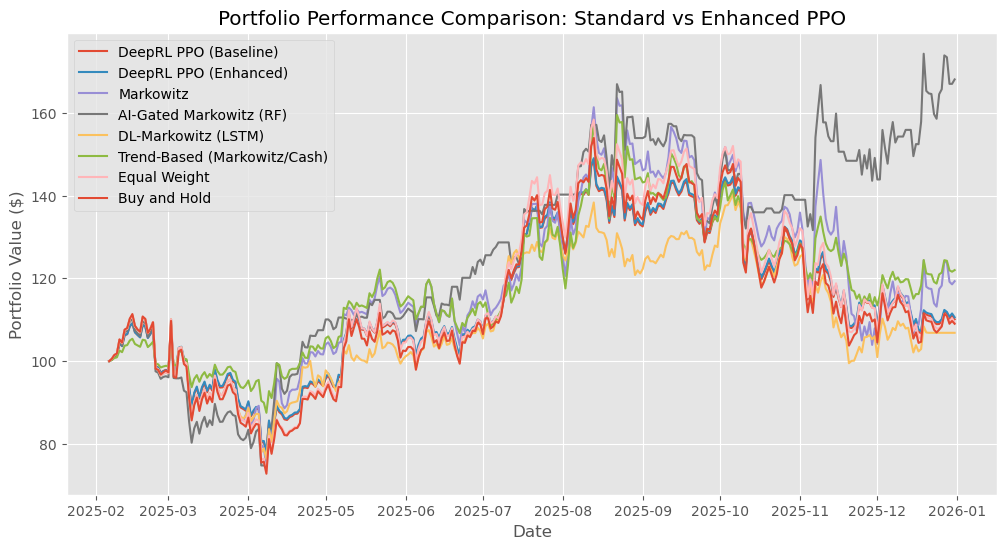

In [18]:
results_df = pd.DataFrame(portfolio_values, index=test_df.index[:len(portfolio_values['DeepRL PPO (Baseline)'])])

metrics = {}
for col in results_df.columns:
    total_return = (results_df[col].iloc[-1] / results_df[col].iloc[0]) - 1
    daily_rets = results_df[col].pct_change().dropna()
    volatility = daily_rets.std() * np.sqrt(252)
    sharpe = (daily_rets.mean() / daily_rets.std()) * np.sqrt(252) if daily_rets.std() > 0 else 0
    metrics[col] = {
        'Total Return': f"{total_return*100:.2f}%",
        'Volatility': f"{volatility*100:.2f}%",
        'Sharpe Ratio': f"{sharpe:.2f}"
    }

metrics_df = pd.DataFrame(metrics).T
print(metrics_df)

plt.figure(figsize=(12, 6))
for col in results_df.columns:
    plt.plot(results_df.index, results_df[col], label=col)
plt.title('Portfolio Performance Comparison: Standard vs Enhanced PPO')
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()